#### Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.inspection import permutation_importance

#### Loading the Saved Model and Preprocessor

In [4]:
# Loading the final trained stacking regression model.

final_model = joblib.load(
    '../models/final_stacking_model.pkl'
)

# Loading the fitted preprocessing pipeline.

preprocessor = joblib.load(
    '../models/preprocessor.pkl'
)

#### Load the Feature-Engineered Data

In [5]:
# Loading the feature-engineered dataset used for model development.

df = pd.read_csv(
    '../data/processed/engineered_data.csv'
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Is_Weekend,Inventory_to_Sales_Ratio,Inventory_Gap,Price_Difference,Price_Difference_Percentage,Promotion_Discount,Previous_Demand,Previous_Units_Sold,Rolling_7_Day_Demand,Rolling_7_Day_Sales
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,1,1.911765,93,-13.01,-15.175551,0,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,...,1,1.309859,22,-8.03,-10.901439,0,115.0,102.0,NaN,NaN
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,...,0,1.929577,132,-12.18,-15.087328,15,84.0,71.0,NaN,NaN
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,...,0,3.142857,90,6.78,12.354227,0,132.0,142.0,NaN,NaN
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,...,0,2.472868,190,2.22,3.871643,25,67.0,42.0,NaN,NaN


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (76000, 31)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Week', 'Day', 'Day_of_Week', 'Is_Weekend', 'Inventory_to_Sales_Ratio', 'Inventory_Gap', 'Price_Difference', 'Price_Difference_Percentage', 'Promotion_Discount', 'Previous_Demand', 'Previous_Units_Sold', 'Rolling_7_Day_Demand', 'Rolling_7_Day_Sales']


#### Separate Features and Target

In [7]:
# Separating the target variable from the input features.

X = df.drop(
    columns=['Demand']
)

y = df['Demand']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (76000, 30)
Target Shape: (76000,)


In [8]:
# Recreating the same train-test split used during model development.

split_index = 63800

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Shape: (63800, 30)
Testing Shape: (12200, 30)
Training Target Shape: (63800,)
Testing Target Shape: (12200,)


#### Transform the Test Data

In [9]:
# Transforming the test features using the fitted preprocessor.

X_test_processed = preprocessor.transform(
    X_test
)

print("Processed Testing Shape:", X_test_processed.shape)

Processed Testing Shape: (12200, 64)


#### Generating Predictions

In [10]:
# Generating predictions from the final stacking model.

y_pred = final_model.predict(
    X_test_processed
)

print("Number of Predictions:", len(y_pred))

Number of Predictions: 12200


#### Permutation Feature Importance

For each feature, the method:

Takes the test data.
Randomly shuffles one feature.
Makes predictions again.
Checks how much the model's performance gets worse.

If shuffling a feature causes a big performance drop:

That feature was important.

If almost nothing changes:

That feature probably wasn't contributing much to the predictions.

##### Calculate Permutation Importance

In [11]:
'''# Calculating permutation importance using the test dataset.
# A small number of repeats is used to keep computation manageable.

permutation_result = permutation_importance(
    final_model,
    X_test_processed,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculated.")'''

'# Calculating permutation importance using the test dataset.\n# A small number of repeats is used to keep computation manageable.\n\npermutation_result = permutation_importance(\n    final_model,\n    X_test_processed,\n    y_test,\n    scoring=\'neg_mean_absolute_error\',\n    n_repeats=3,\n    random_state=42,\n    n_jobs=-1\n)\n\nprint("Permutation importance calculated.")'

In [12]:
# Creating a small representative sample for explainability.

X_explain = X_test_processed[:500]
y_explain = y_test.iloc[:500]

print("Explainability Sample Shape:", X_explain.shape)
print("Explainability Target Shape:", y_explain.shape)

Explainability Sample Shape: (500, 64)
Explainability Target Shape: (500,)


##### Lightweight Permutation Importance

In [13]:
# Calculating lightweight permutation importance.

permutation_result = permutation_importance(
    final_model,
    X_explain,
    y_explain,
    scoring='neg_mean_absolute_error',
    n_repeats=1,
    random_state=42,
    n_jobs=1
)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


##### Getting the Processed Feature Names

In [14]:
# Extracting the feature names generated by the preprocessing pipeline.

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 64

First 20 features:
['categorical__Store ID_S001' 'categorical__Store ID_S002'
 'categorical__Store ID_S003' 'categorical__Store ID_S004'
 'categorical__Store ID_S005' 'categorical__Product ID_P0001'
 'categorical__Product ID_P0002' 'categorical__Product ID_P0003'
 'categorical__Product ID_P0004' 'categorical__Product ID_P0005'
 'categorical__Product ID_P0006' 'categorical__Product ID_P0007'
 'categorical__Product ID_P0008' 'categorical__Product ID_P0009'
 'categorical__Product ID_P0010' 'categorical__Product ID_P0011'
 'categorical__Product ID_P0012' 'categorical__Product ID_P0013'
 'categorical__Product ID_P0014' 'categorical__Product ID_P0015']


##### Building the Proper Importance Table

In [15]:
# Creating a feature importance table with meaningful processed feature names.

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': permutation_result.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance
0,numerical__Inventory_to_Sales_Ratio,34.216962
1,numerical__Inventory Level,22.522068
2,numerical__Units Ordered,11.245528
3,numerical__Promotion,3.468985
4,numerical__Inventory_Gap,2.406649
5,numerical__Epidemic,2.400952
6,categorical__Seasonality_Summer,2.384696
7,categorical__Weather Condition_Sunny,2.328203
8,numerical__Rolling_7_Day_Demand,1.816906
9,numerical__Previous_Demand,1.081752


The big finding

Inventory_to_Sales_Ratio is far ahead of everything else.

Inventory_to_Sales_Ratio   34.22
Inventory Level            22.52
Units Ordered              11.25
Promotion                    3.47
...

That means the model's predictions are particularly sensitive to the information contained in the inventory-to-sales ratio.

But I don't want us to immediately declare that this is the most important business driver of Demand.

Why?

Because we need to verify how that feature was constructed.

If Inventory_to_Sales_Ratio uses information that would only be known after or at the same time as the Demand we're trying to predict, it could introduce target leakage or make the feature unrealistic for forecasting.

That's especially important for a project like ours.

##### Inspecting the Feature Engineering

In [16]:
# Inspecting the inventory-to-sales ratio.

df[
    [
        'Inventory Level',
        'Units Sold',
        'Inventory_to_Sales_Ratio'
    ]
].head(10)

,Inventory Level,Units Sold,Inventory_to_Sales_Ratio
0,195,102,1.911765
1,93,71,1.309859
2,274,142,1.929577
3,132,42,3.142857
4,319,129,2.472868
5,190,98,1.938776
6,92,92,1.000000
7,308,96,3.208333
8,212,57,3.719298
9,403,88,4.579545


In [17]:
# Checking the relationship between the ratio and its component variables.

df[
    [
        'Inventory Level',
        'Units Sold',
        'Inventory_to_Sales_Ratio'
    ]
].describe()

,Inventory Level,Units Sold,Inventory_to_Sales_Ratio
count,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,4.278367
std,226.510161,43.994525,5.428139
min,0.000000,0.000000,0.000000
25%,136.000000,58.000000,1.539063
50%,227.000000,84.000000,2.836002
75%,408.000000,114.000000,5.222222
max,2267.000000,426.000000,317.500000


So the feature is directly calculated using Units Sold from the same observation.

Why does that matter?

Our target is:

Demand

If our real-world prediction scenario is:

"Predict future Demand before today's sales happen"

then Units Sold from that same period would not be available yet.

In that scenario, this feature could be considered target leakage / look-ahead information, depending on exactly when Demand is defined relative to Units Sold.

And look at what happened:

Inventory_to_Sales_Ratio → 34.22 importance

That's enormous compared with the next feature:

Inventory Level → 22.52

So we absolutely need to investigate this before presenting Inventory_to_Sales_Ratio as the model's most important business driver.

##### Check Our Original Feature Engineering

In [18]:
# Checking the feature-engineered columns that may contain current-period information.

print([
    'Inventory_to_Sales_Ratio',
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Inventory_Gap',
    'Previous_Demand',
    'Previous_Units_Sold',
    'Rolling_7_Day_Demand',
    'Rolling_7_Day_Sales'
])

['Inventory_to_Sales_Ratio', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Inventory_Gap', 'Previous_Demand', 'Previous_Units_Sold', 'Rolling_7_Day_Demand', 'Rolling_7_Day_Sales']


In [19]:
# Inspecting potentially leakage-prone features.

df[
    [
        'Units Sold',
        'Inventory Level',
        'Inventory_to_Sales_Ratio',
        'Inventory_Gap',
        'Previous_Demand',
        'Previous_Units_Sold',
        'Rolling_7_Day_Demand',
        'Rolling_7_Day_Sales'
    ]
].head(10)

,Units Sold,Inventory Level,Inventory_to_Sales_Ratio,Inventory_Gap,Previous_Demand,Previous_Units_Sold,Rolling_7_Day_Demand,Rolling_7_Day_Sales
0,102,195,1.911765,93,NaN,NaN,NaN,NaN
1,71,93,1.309859,22,115.0,102.0,NaN,NaN
2,142,274,1.929577,132,84.0,71.0,NaN,NaN
3,42,132,3.142857,90,132.0,142.0,NaN,NaN
4,129,319,2.472868,190,67.0,42.0,NaN,NaN
5,98,190,1.938776,92,110.0,129.0,NaN,NaN
6,92,92,1.000000,0,146.0,98.0,NaN,NaN
7,96,308,3.208333,212,87.0,92.0,105.857143,96.571429
8,57,212,3.719298,155,113.0,96.0,105.571429,95.714286
9,88,403,4.579545,315,87.0,57.0,106.000000,93.714286


Inventory_to_Sales_Ratio is definitely using current-row Units Sold, so we should not treat its huge permutation importance as a clean business insight for a future-demand forecasting model.

There's another important issue

Inventory_Gap = Inventory Level - Units Sold

That also uses current-period Units Sold.

Therefore, if our intended use case is:

- Predict Demand before current-period sales occur

then both:

- Inventory_to_Sales_Ratio
- Inventory_Gap

are potentially leakage-prone.

What about Units Sold itself?

This is even more important.

Our model currently has:

- Units Sold

as an input feature.

If Demand is effectively the demand we're trying to predict for that same period, using current Units Sold is problematic too.

We've already completed our modeling and evaluation pipeline, and we have a strong model:

R² ≈ 0.903

Instead, in explainability we'll be transparent about the feature design.

But before writing the final explainability conclusions, we should determine whether Demand and Units Sold are conceptually separate variables in this dataset or whether Demand is calculated/observed independently.

In [20]:
# Checking the relationship between Demand and Units Sold.

df[['Demand', 'Units Sold']].corr()

,Demand,Units Sold
Demand,1.000000,0.833421
Units Sold,0.833421,1.000000


In [21]:
# Comparing Demand and Units Sold.

df[['Demand', 'Units Sold']].describe()

,Demand,Units Sold
count,76000.000000,76000.000000
mean,104.317158,88.827316
std,46.964801,43.994525
min,4.000000,0.000000
25%,71.000000,58.000000
50%,100.000000,84.000000
75%,133.000000,114.000000
max,430.000000,426.000000


So Units Sold is clearly carrying a lot of information about Demand.

But here's the key distinction:

- Correlation ≠ leakage.

Leakage depends on when the information is available relative to the prediction being made.

We have three types of features.

🟢 Clearly historical
- Previous_Demand
- Previous_Units_Sold
- Rolling_7_Day_Demand
- Rolling_7_Day_Sales

🟡 Potentially problematic

- Inventory_to_Sales_Ratio
- Inventory_Gap

🔴 Potentially problematic

- Units Sold

#### Conclusion

The model incorporates contemporaneous operational variables such as Units Sold and derived inventory-related features. These variables may provide strong predictive information, but their availability should be verified against the intended deployment timeline. For true pre-demand forecasting, future iterations should restrict features to information available before the prediction period.

#### Top Feature Importance

In [22]:
# Selecting the 15 most important processed features.

top_features = importance_df.head(15)

top_features

,Feature,Importance
0,numerical__Inventory_to_Sales_Ratio,34.216962
1,numerical__Inventory Level,22.522068
2,numerical__Units Ordered,11.245528
3,numerical__Promotion,3.468985
4,numerical__Inventory_Gap,2.406649
5,numerical__Epidemic,2.400952
6,categorical__Seasonality_Summer,2.384696
7,categorical__Weather Condition_Sunny,2.328203
8,numerical__Rolling_7_Day_Demand,1.816906
9,numerical__Previous_Demand,1.081752


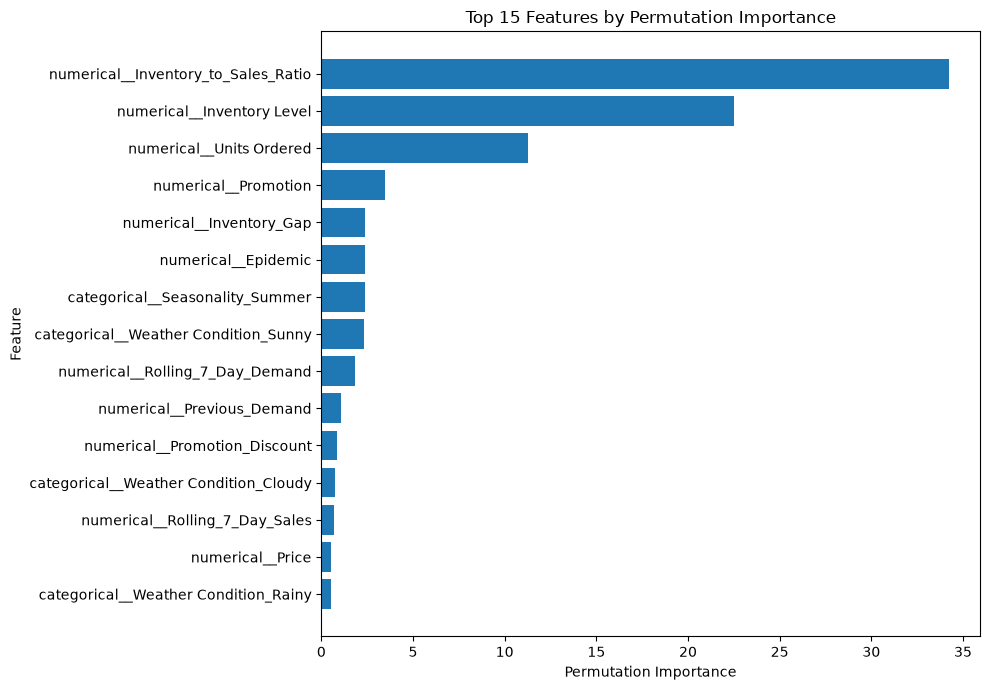

In [23]:
# Visualizing the top 15 features based on permutation importance.

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features by Permutation Importance')

plt.tight_layout()

plt.show()

"The model's predictions are highly sensitive to inventory-related features, particularly Inventory-to-Sales Ratio and Inventory Level. However, because some inventory-derived variables incorporate contemporaneous Units Sold information, their importance should be interpreted with caution in a true pre-demand forecasting scenario."

In [24]:
# Inspecting the preprocessing pipeline.

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

For categorical variables, we want to combine their individual one-hot columns back into their original feature:

Category_Clothing
Category_Electronics
Category_Furniture
Category_Groceries
Category_Toys
             ↓
          Category

Likewise:

Weather Condition_Sunny
Weather Condition_Rainy
Weather Condition_Cloudy
Weather Condition_Snowy
             ↓
      Weather Condition

For numerical features, there's nothing to combine.

##### Aggregate Importance to Original Features

In [25]:
# Creating feature-level importance by combining one-hot encoded categories.

importance_df['Original_Feature'] = importance_df['Feature'].str.replace(
    r'^(numerical__|categorical__)',
    '',
    regex=True
)

# Removing the specific category values from one-hot encoded features.
categorical_features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

for feature in categorical_features:
    mask = importance_df['Original_Feature'].str.startswith(
        feature + '_'
    )
    
    importance_df.loc[mask, 'Original_Feature'] = feature

# Aggregating permutation importance by original feature.
original_feature_importance = (
    importance_df
    .groupby('Original_Feature')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

original_feature_importance.head(15)

,Original_Feature,Importance
0,Inventory_to_Sales_Ratio,34.216962
1,Inventory Level,22.522068
2,Units Ordered,11.245528
3,Weather Condition,3.707749
4,Promotion,3.468985
5,Seasonality,2.956935
6,Inventory_Gap,2.406649
7,Epidemic,2.400952
8,Rolling_7_Day_Demand,1.816906
9,Previous_Demand,1.081752
